# Notebook 0 : Potientiel φ

**Objectif** : Déterminer le potentiel φ sur l'ensemble du labyrinthe

**Fichiers utilisés** : 'laby.png'
**Fichiers produits** : 'domaine.txt.npy` et `V.npy`.

In [1]:
import os

os.chdir(r"C:\Users\cerda\OneDrive\Bureau\Année 5\Methodes numeriques lineaire")

print(os.getcwd())

C:\Users\cerda\OneDrive\Bureau\Année 5\Methodes numeriques lineaire


A_top: 209276it [00:01, 126196.91it/s]
A_bottom: 209276it [00:01, 130071.49it/s]
A_left: 209276it [00:01, 139820.91it/s]
A_right: 209276it [00:01, 130873.06it/s]
A_center: 209276it [00:04, 49540.54it/s]


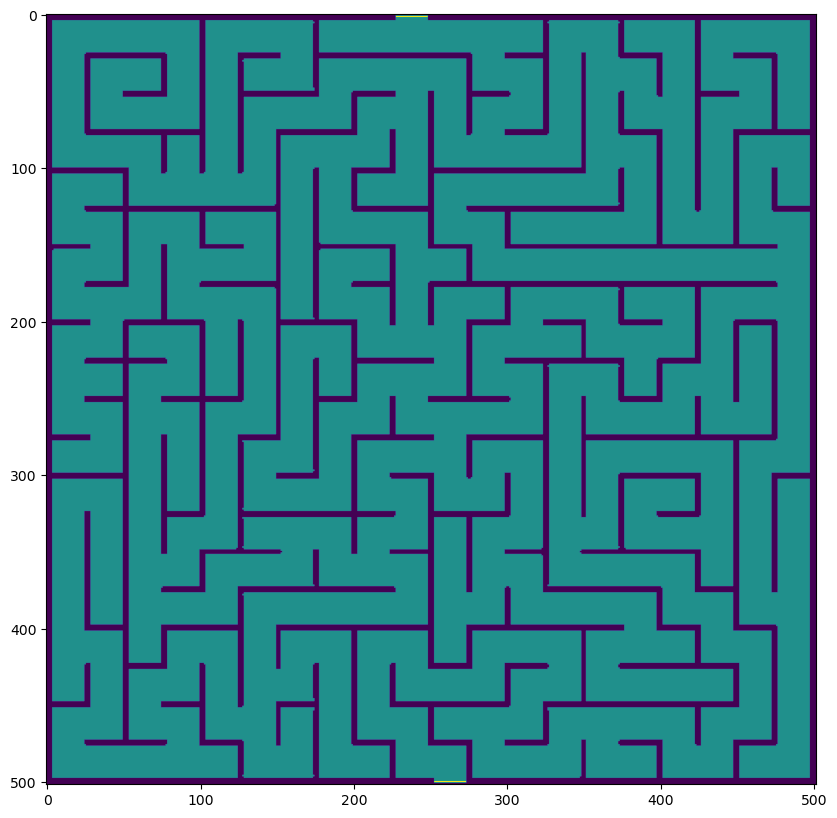

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csc_array as csr
from scipy.sparse.linalg import spsolve, gmres, cg, splu
from tqdm import tqdm

def laplace_pot(domain, outside_value = 0, inside_value = 1, pot_in = 1., pot_out = -1.):
    """
    Calcul d'un écoulement irrotationnel en potentiel de vitesse sur base d'une matrice de domaine

    outside_value = valeur considérée hors domaine
    inside_value  = valeur considérée dans le domaine de calcul
    pot_in        = potentiel imposé en entrée
    pot_out       = potentiel imposé en sortie
    """
    # recherche de la zone permettant de circonscrir la zone hors domaine
    outside= np.where(domain==outside_value)
    i1 = outside[0].min()
    i2 = outside[0].max()
    j1 = outside[1].min()
    j2 = outside[1].max()

    # Restriction de la matrice à la zone utile
    domain=domain[i1:i2+1,j1:j2+1]

    # Recherche des coordonnées hors et dans le domaine
    outside= np.where(domain==outside_value)
    inside = np.where(domain==inside_value)

    # Nombre de points de calcul
    nb = len(inside[0])

    # Matrice de numérotation
    numb_vec  = np.arange(0, nb, dtype=np.int32)
    #   Utilisation d'un stockage CSR par facilité --> mais "lent" pour la recherche des voisins (environ 60x plus lent pour l'image d'exemple)
    # numbering = csr((numb_vec, (inside[0], inside[1])), shape=array.shape)
    #
    # Utilisation d'une matrice pleine --> plus "rapide" pour la recherche des voisins mais demande éventuellement plus de mémoire
    numbering = np.zeros(domain.shape, dtype=np.int32)
    numbering[inside] = numb_vec

    # Recherche des zones CL
    #  - amont : ligne supérieure
    #  - aval : ligne inférieure
    inlet  = np.where(domain[0,:]==inside_value)[0]
    outlet = np.where(domain[-1,:]==inside_value)[0]

    b  = np.zeros(nb)
    b[0:len(inlet)] = pot_in
    b[-len(outlet):]= pot_out

    # Remplissage de la matrice de poids en CSR
    # *****************************************
    # Création par "List comprehension"
    Aij_inlet  = [ [1., numbering[0 ,j], numbering[0  ,j  ]] for j in list(inlet)]
    Aij_outlet = [ [1., numbering[-1,j], numbering[-1 ,j  ]] for j in list(outlet)]

    Aij_top    = [ [1., numbering[i ,j], numbering[i-1,j  ]] for i,j in tqdm(zip(inside[0], inside[1]), 'A_top')    if i!=0 and i!=domain.shape[0]-1 if domain[i-1,j  ] == inside_value]
    Aij_bottom = [ [1., numbering[i ,j], numbering[i+1,j  ]] for i,j in tqdm(zip(inside[0], inside[1]), 'A_bottom') if i!=0 and i!=domain.shape[0]-1 if domain[i+1,j  ] == inside_value]
    Aij_left   = [ [1., numbering[i ,j], numbering[i  ,j-1]] for i,j in tqdm(zip(inside[0], inside[1]), 'A_left')   if i!=0 and i!=domain.shape[0]-1 if domain[i  ,j-1] == inside_value]
    Aij_right  = [ [1., numbering[i ,j], numbering[i  ,j+1]] for i,j in tqdm(zip(inside[0], inside[1]), 'A_right')  if i!=0 and i!=domain.shape[0]-1 if domain[i  ,j+1] == inside_value]

    def count_neigh(i,j):
        count = 0
        if domain[i-1,j] == inside_value:
            count+=1
        if domain[i+1,j] == inside_value:
            count+=1
        if domain[i,j-1] == inside_value:
            count+=1
        if domain[i,j+1] == inside_value:
            count+=1

        return float(count)

    Aij_center = [ [-count_neigh(i,j), numbering[i,j], numbering[i,j]] for i,j in tqdm(zip(inside[0], inside[1]), 'A_center') if i!=0 and i!=domain.shape[0]-1]

    A_parts = [Aij_inlet, Aij_outlet, Aij_left, Aij_right, Aij_bottom, Aij_top, Aij_center]
    A  = [cur[0] for cur_part in A_parts for cur in cur_part]
    ii = [cur[1] for cur_part in A_parts for cur in cur_part]
    jj = [cur[2] for cur_part in A_parts for cur in cur_part]

    # Création de la CSR sur base des vecteurs de valeurs et des indices de position
    csr_a = csr((A,(ii,jj)))

    # Résolution du système
    x = spsolve(csr_a,b)

    # Remplissage de la matrice de résultat sur base du vecteur x
    pot = np.zeros(domain.shape, dtype=np.float64)
    pot[inside] = x

    # Classification du domaine selon la convention
    #   - 0 = hors domaine
    #   - 1 = domaine intérieur
    #   - 2 = conditions limites
    domain[outside] = 0
    domain[inside]  = 1
    domain[0,inlet]   = 2
    domain[-1,outlet]  = 2

    #ajout d'un bord de 0 sur tout le pourtour
    new_dom = np.zeros((domain.shape[0]+2, domain.shape[1]+2), dtype=np.int32)
    new_dom[1:-1,1:-1] = np.int32(domain)
    new_pot = np.zeros((domain.shape[0]+2, domain.shape[1]+2), dtype=np.float64)
    new_pot[1:-1,1:-1] = pot


    return new_dom, new_pot

def compute(filepath:str, fileout:str = 'out'):
    # Import du module PIL pour lire n'importe quelle image
    from PIL import Image
    # Lecture d'une image
    im = Image.open(filepath)

    # Conversion de l'image en matrice Numpy
    array = np.asarray(im)[:,:,0].copy() # uniquement la composante R d'une image RGB --> à particulariser si l'image est pure N&B par exemple

    # La matrice contient des valeurs comprises entre 0 et 255

    # Filtrage du 'gris' --> image N&B
    #  seuil arbitraire à 200
    array[np.where(array<=200)]= 0
    array[np.where(array>200)] = 1

    # Calcul du laplacien du potentiel
    domain, pot = laplace_pot(array,
                            outside_value=0,
                            inside_value=1,
                            pot_in=100.,
                            pot_out=-100.)

    fig, ax = plt.subplots(1,1)
    fig.set_size_inches(10,10)
    ax.imshow(pot)
    fig.savefig(fileout+'.png')

    ax.imshow(domain)
    fig.savefig('domain.png')

    np.savetxt(fileout+'_domain.txt', domain, fmt='%i')
    np.savetxt(fileout+'_pot.txt', pot, fmt='%15.10f')
    np.save(fileout+'_pot.npy', pot)

if __name__ == "__main__":

    compute('laby.png', 'out')